## Problema 8 - Minimos cuadrados con Newton-Raphson multidimensional
### Consideraciones para la Resolución

* **Utilizar seis decimales para los resultados.**
* **Utilizar todos los decimales para los calculos.**
* **No utilizar formato exponencial (notacion científica).**
* **Utilizar una tolerancia de $10^{-3}$.**
* **No modificar los valores iniciales ni la tolerancia para los calculos.**
* **No es necesario realizar ninguna conversion de unidades.**

Determinar los coeficientes de modo a que la curva de regresión se ajuste lo mejor posible a los datos. UTILIZAR el método de Newton Raphson generalizado para minimizar el error cuadrático medio siendo el modelo propuesto:

$$
y=(Ax+B)^{-2}
$$

Los datos para el ajuste son:

| x | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 |
|---|---|---|---|---|---|---|---|---|---|
| y | 4.09 | 2.47 | 1.62 | 1.11 | 0.89 | 0.63 | 0.49 | 0.45 | 0.39 |


_Planteamiento_

Siendo $y = (Ax+B)^{-2}$ el modelo propuesto, el objetivo de la regresión es determinar $A$ y $B$ tal que se minimice el error cuadrático medio en el conjunto de puntos $(x_1, y_1), \ldots, (x_n, y_n)$.

Es decir, minimizar:
$$ECM_y = \frac{1}{n}\sum_{i=1}^{n}(y_i-y(x_i))^2$$
En terminos de optimizacion se traduce a resolver $\nabla ECM_y = 0$, es decir:
$$\frac{\partial ECM_y}{\partial A} = 0 \quad \text{(1)}$$
$$\frac{\partial ECM_y}{\partial B} = 0 \quad \text{(2)}$$

Sin embargo, para determinar si el modelo es adecuado, este debe ser transformado a un formato $z = aw + b$, de modo a emplear el coeficiente de determinación
$$
R^2 = 1-\frac{\sum_{i=1}^{n}(z_i-z(w_i))^2}{\sum_{i=1}^{n}(z_i-\bar{z})^2}
$$

El modelo es adecuado si $R^2 \geq 0.7$.

Manipulando la ecuación original

$$
y^{-1/2} = Ax + B
$$

Entoces si $z = y^{-1/2}$ y $w = x$, resulta: el modelo $z = A - B\cdot w^{-1/2}$ y los datos se transforma a

| x | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 |
|---|---|---|---|---|---|---|---|---|---|
| z | $4.09^{-1/2}$ | $2.47^{-1/2}$ | $1.62^{-1/2}$ | $1.11^{-1/2}$ | $0.89^{-1/2}$ | $0.63^{-1/2}$ | $0.49^{-1/2}$ | $0.45^{-1/2}$ | $0.39^{-1/2}$ |

El Error Cuadrático Medio es:
$$
ECM_z = \frac{1}{n}\sum_{i=1}^{n}(z_i-z(w_i))^2
$$
Y el sistema de a resolver es:
$$\frac{\partial ECM_z}{\partial A} = 0 \quad \text{(1)}$$
$$\frac{\partial ECM_z}{\partial B} = 0 \quad \text{(2)}$$


In [ ]:
import jax.numpy as jnp
from jax import grad
from jax import jacfwd

# Definimos los datos originales
x_data = jnp.array([1,2,3,4,5,6,7,8,9],dtype=float)
y_data = jnp.array([4.09,2.47,1.62,1.11,0.89,0.63,0.49,0.45,0.39],dtype=float)

# Transformacion de los datos
z_data = jnp.pow(y_data, -1/2)

# Definimos el modelo original
def y(x,A,B):
    return jnp.pow(A*x+B, -2)

# Definimos el modelo trasformado
def z(x,A,B):
    #return A*x + B
    return jnp.pow(y(x,A,B), -1/2)

# Definimos el ECM
def ecm(var):
    A,B = var
    return jnp.mean(jnp.pow(z(x_data,A,B)-z_data,2))

sistema = grad(ecm)
jacob_sist=jacfwd(sistema)

# Parametros de inicializacion
P0 = jnp.array([0.0, 1.0], dtype=float)
tol = 1e-3
m = 100

################RUTINA009##########################
for i in range(m):
    F = sistema(P0)
    J = jacob_sist(P0)
    deltaP = jnp.linalg.solve(J, -F)
    P = P0 + deltaP
    err = jnp.linalg.norm(deltaP)
    relerr = err / jnp.linalg.norm(P)
    f_norm = jnp.linalg.norm(F)
    if (err < tol) or (relerr < tol) or (f_norm < tol):
        P0 = P
        break
    P0 = P

print("Analisis de convergencia:")
print("Error absoluto: ", err)
print("Error relativo: ", relerr)
print("Cantidad de iteraciones: ", i+1)
print("Valor de |F(P)|: ", f_norm)

print("------------------")
A_res, B_res = P

print("Valor de A: ", jnp.around(A_res,6))
print("Valor de B: ", jnp.around(B_res,6))

print("------------------")
print("Coeficiente de determinacion: ")
z_pred = z(x_data, A_res, B_res)
z_media = jnp.mean(z_data)

ss_res = jnp.sum(jnp.pow(z_data - z_pred, 2))
ss_tot = jnp.sum(jnp.pow(z_data - z_media, 2))

r2 = 1 - (ss_res / ss_tot)
print("R2: ", r2)


Analisis de convergencia:
Error absoluto:  3.3557683e-07
Error relativo:  8.60312e-07
Cantidad de iteraciones:  2
Valor de |F(P)|:  4.6664465e-07
------------------
Valor de A:  0.143118
Valor de B:  0.36286
------------------
Coeficiente de determinacion: 
R2:  0.99258834


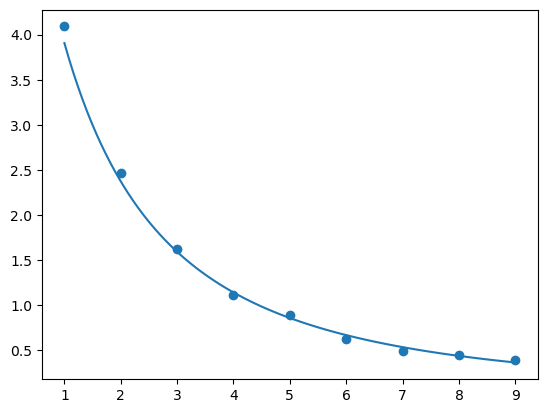

In [ ]:
import matplotlib.pyplot as plt

xf = jnp.linspace(x_data.min(), x_data.max(), 100)
yf = y(xf, A_res, B_res)

plt.scatter(x_data, y_data)
plt.plot(xf, yf)